In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             roc_auc_score, confusion_matrix,
                             classification_report)

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
df = pd.read_csv('../data/processed/hotel_bookings_cleaned.csv')
print(f"Dataset loaded! Shape: {df.shape}")

Dataset loaded! Shape: (119390, 35)


In [4]:
features = [
    'lead_time',
    'previous_cancellations',
    'total_of_special_requests',
    'is_repeated_guest',
    'booking_changes',
    'total_nights',
    'total_guests',
    'adr',
    'days_in_waiting_list',
    'required_car_parking_spaces'
]

target = 'is_canceled'

print("Features selected:", len(features))
print("Target:", target)

Features selected: 10
Target: is_canceled


In [5]:
df_model = pd.get_dummies(df, columns=['hotel', 'market_segment', 
                                        'deposit_type', 'customer_type'])

print("Shape after encoding:", df_model.shape)
print("New columns added:", df_model.shape[1] - df.shape[1])

Shape after encoding: (119390, 48)
New columns added: 13


In [6]:
encoded_features = [col for col in df_model.columns 
                    if col.startswith('hotel_') 
                    or col.startswith('market_segment_')
                    or col.startswith('deposit_type_')
                    or col.startswith('customer_type_')]

all_features = features + encoded_features

print("Total features for model:", len(all_features))
print("\nAll features:")
for f in all_features:
    print(f" -", f)

Total features for model: 27

All features:
 - lead_time
 - previous_cancellations
 - total_of_special_requests
 - is_repeated_guest
 - booking_changes
 - total_nights
 - total_guests
 - adr
 - days_in_waiting_list
 - required_car_parking_spaces
 - hotel_City Hotel
 - hotel_Resort Hotel
 - market_segment_Aviation
 - market_segment_Complementary
 - market_segment_Corporate
 - market_segment_Direct
 - market_segment_Groups
 - market_segment_Offline TA/TO
 - market_segment_Online TA
 - market_segment_Undefined
 - deposit_type_No Deposit
 - deposit_type_Non Refund
 - deposit_type_Refundable
 - customer_type_Contract
 - customer_type_Group
 - customer_type_Transient
 - customer_type_Transient-Party


In [7]:
X = df_model[all_features]
y = df_model[target]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nCancellation distribution:")
print(y.value_counts())
print(f"\nNot Cancelled: {y.value_counts()[0]}")
print(f"Cancelled:     {y.value_counts()[1]}")

X shape: (119390, 27)
y shape: (119390,)

Cancellation distribution:
is_canceled
0    75166
1    44224
Name: count, dtype: int64

Not Cancelled: 75166
Cancelled:     44224


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"Training set:  {X_train.shape[0]} rows")
print(f"Testing set:   {X_test.shape[0]} rows")
print(f"Total:         {X_train.shape[0] + X_test.shape[0]} rows")

Training set:  95512 rows
Testing set:   23878 rows
Total:         119390 rows


In [9]:
lr_model = LogisticRegression(max_iter=2000, random_state=42)

lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

print("Logistic Regression trained successfully!")
print(f"First 10 predictions: {lr_predictions[:10]}")

Logistic Regression trained successfully!
First 10 predictions: [0 1 0 0 1 1 0 0 0 0]


In [10]:
lr_accuracy  = accuracy_score(y_test, lr_predictions)
lr_precision = precision_score(y_test, lr_predictions)
lr_recall    = recall_score(y_test, lr_predictions)
lr_f1        = f1_score(y_test, lr_predictions)
lr_roc_auc   = roc_auc_score(y_test, lr_predictions)

print("=== Logistic Regression Results ===")
print(f"Accuracy:  {round(lr_accuracy  * 100, 2)}%")
print(f"Precision: {round(lr_precision * 100, 2)}%")
print(f"Recall:    {round(lr_recall    * 100, 2)}%")
print(f"F1 Score:  {round(lr_f1        * 100, 2)}%")
print(f"ROC AUC:   {round(lr_roc_auc   * 100, 2)}%")

=== Logistic Regression Results ===
Accuracy:  80.71%
Precision: 84.71%
Recall:    59.36%
F1 Score:  69.8%
ROC AUC:   76.46%


In [11]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

print("Random Forest trained successfully!")
print(f"First 10 predictions: {rf_predictions[:10]}")

Random Forest trained successfully!
First 10 predictions: [0 1 0 0 0 1 1 0 0 0]


In [12]:
rf_accuracy  = accuracy_score(y_test, rf_predictions)
rf_precision = precision_score(y_test, rf_predictions)
rf_recall    = recall_score(y_test, rf_predictions)
rf_f1        = f1_score(y_test, rf_predictions)
rf_roc_auc   = roc_auc_score(y_test, rf_predictions)

print("=== Random Forest Results ===")
print(f"Accuracy:  {round(rf_accuracy  * 100, 2)}%")
print(f"Precision: {round(rf_precision * 100, 2)}%")
print(f"Recall:    {round(rf_recall    * 100, 2)}%")
print(f"F1 Score:  {round(rf_f1        * 100, 2)}%")
print(f"ROC AUC:   {round(rf_roc_auc   * 100, 2)}%")

=== Random Forest Results ===
Accuracy:  85.18%
Precision: 83.25%
Recall:    75.8%
F1 Score:  79.35%
ROC AUC:   83.31%


In [13]:
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC'],
    'Logistic Regression': [
        round(lr_accuracy * 100, 2),
        round(lr_precision * 100, 2),
        round(lr_recall * 100, 2),
        round(lr_f1 * 100, 2),
        round(lr_roc_auc * 100, 2)
    ],
    'Random Forest': [
        round(rf_accuracy * 100, 2),
        round(rf_precision * 100, 2),
        round(rf_recall * 100, 2),
        round(rf_f1 * 100, 2),
        round(rf_roc_auc * 100, 2)
    ]
})

print("=== Model Comparison ===")
comparison

=== Model Comparison ===


,Metric,Logistic Regression,Random Forest
0,Accuracy,80.71,85.18
1,Precision,84.71,83.25
2,Recall,59.36,75.80
3,F1 Score,69.80,79.35
4,ROC AUC,76.46,83.31


In [14]:
importance_df = pd.DataFrame({
    'feature': all_features,
    'importance': rf_model.feature_importances_
})
importance_df = importance_df.sort_values('importance', ascending=False)

print("Top 10 Most Important Features:")
importance_df.head(10)

Top 10 Most Important Features:


,feature,importance
0,lead_time,0.259216
7,adr,0.222792
21,deposit_type_Non Refund,0.096852
20,deposit_type_No Deposit,0.086351
5,total_nights,0.065810
2,total_of_special_requests,0.055483
1,previous_cancellations,0.042080
18,market_segment_Online TA,0.029393
6,total_guests,0.023260
9,required_car_parking_spaces,0.022623


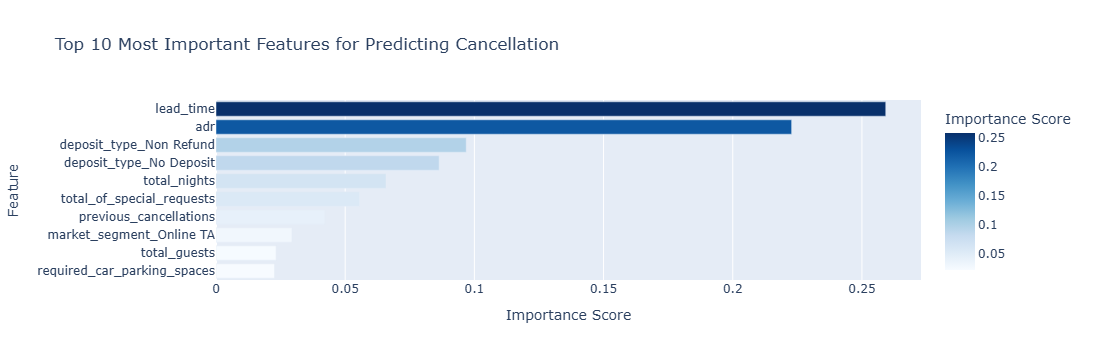

In [15]:
fig_importance = px.bar(
    importance_df.head(10),
    x='importance',
    y='feature',
    orientation='h',
    title='Top 10 Most Important Features for Predicting Cancellation',
    labels={'importance': 'Importance Score', 'feature': 'Feature'},
    color='importance',
    color_continuous_scale='Blues'
)

fig_importance.update_layout(yaxis={'categoryorder': 'total ascending'})
fig_importance.show()

In [16]:
cm = confusion_matrix(y_test, rf_predictions)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[13539  1368]
 [ 2171  6800]]


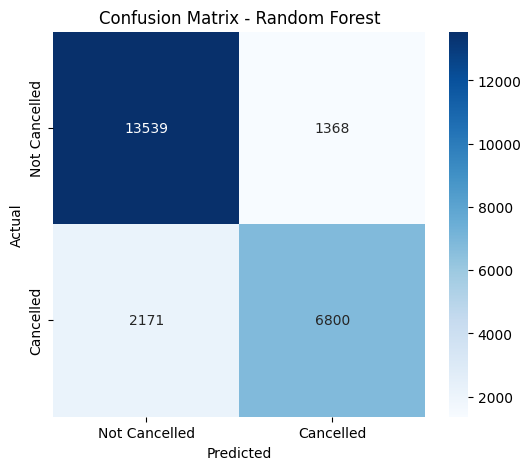

In [17]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Cancelled', 'Cancelled'],
            yticklabels=['Not Cancelled', 'Cancelled'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()

In [18]:
print("=== Detailed Classification Report ===")
print(classification_report(y_test, rf_predictions, 
                            target_names=['Not Cancelled', 'Cancelled']))

=== Detailed Classification Report ===
               precision    recall  f1-score   support

Not Cancelled       0.86      0.91      0.88     14907
    Cancelled       0.83      0.76      0.79      8971

     accuracy                           0.85     23878
    macro avg       0.85      0.83      0.84     23878
 weighted avg       0.85      0.85      0.85     23878



In [19]:
import joblib

joblib.dump(rf_model, '../src/cancellation_model.pkl')

print("Model saved successfully!")
print("Location: src/cancellation_model.pkl")

Model saved successfully!
Location: src/cancellation_model.pkl


In [20]:
import os

os.makedirs('../dashboards/screenshots', exist_ok=True)

fig_importance.write_html('../dashboards/screenshots/chart13_feature_importance.html')

print("Chart saved successfully!")

Chart saved successfully!


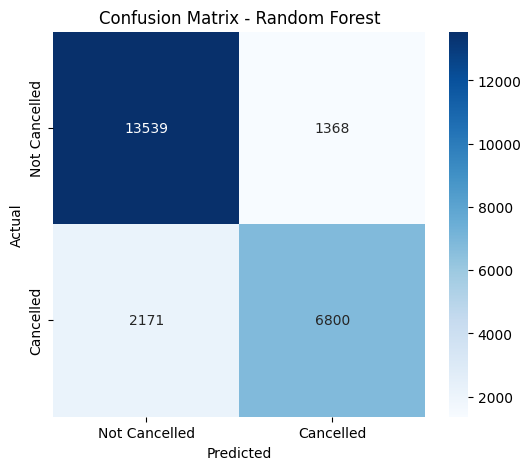

Confusion matrix saved as image!


In [21]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Cancelled', 'Cancelled'],
            yticklabels=['Not Cancelled', 'Cancelled'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')

plt.savefig('../dashboards/screenshots/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("Confusion matrix saved as image!")

In [22]:
comparison.to_csv('../reports/model_comparison.csv', index=False)

importance_df.to_csv('../reports/feature_importance.csv', index=False)

print("All results saved successfully!")

All results saved successfully!
